# 03_Home_Credit_PD_Scorecard_Advanced_Monitoring_and_Stability

## Purpose

This notebook adds the next practical upgrades after a working PD scorecard:

1. monotonic manual bin review  
2. population stability index (PSI) by score band  
3. reject inference discussion  
4. time-based validation split  
5. calibration to long-run or through-the-cycle PD  
6. score-to-grade mapping with portfolio default benchmarks  

This notebook is written for portfolio presentation. It is designed to show how a scorecard moves from a modelling exercise into a more bank-style monitoring and governance workflow.

## 1. Setup

Update the file paths below to match your local project structure.

Expected inputs:
- processed scorecard outputs from Notebook 1
- validation outputs or scored data from Notebook 2
- modelling base with a date field if available

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path("..")
PROCESSED_DIR = Path("../outputs/tables/scorecard_outputs")
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

score_band_summary_path = PROCESSED_DIR / "10_score_band_summary.csv"
train_scored_path = PROCESSED_DIR / "05_train_scored.csv"
test_scored_path = PROCESSED_DIR / "06_test_scored.csv"
woe_table_path = PROCESSED_DIR / "02_woe_table.csv"

print("Processed directory:", PROCESSED_DIR)

Processed directory: ..\output\scorecard_outputs


## 2. Helper functions

These helpers support:
- PSI calculation
- monotonic bad-rate review
- calibration tables
- score-to-grade mapping

In [2]:
def population_stability_index(expected, actual, eps=1e-6):
    expected = np.asarray(expected, dtype=float)
    actual = np.asarray(actual, dtype=float)
    expected = np.where(expected <= 0, eps, expected)
    actual = np.where(actual <= 0, eps, actual)
    return np.sum((actual - expected) * np.log(actual / expected))

def psi_by_band(expected_counts, actual_counts, labels=None, eps=1e-6):
    expected_counts = np.asarray(expected_counts, dtype=float)
    actual_counts = np.asarray(actual_counts, dtype=float)

    expected_dist = expected_counts / expected_counts.sum()
    actual_dist = actual_counts / actual_counts.sum()

    expected_dist = np.where(expected_dist <= 0, eps, expected_dist)
    actual_dist = np.where(actual_dist <= 0, eps, actual_dist)

    psi_component = (actual_dist - expected_dist) * np.log(actual_dist / expected_dist)

    out = pd.DataFrame({
        "band": labels if labels is not None else np.arange(len(expected_counts)),
        "expected_count": expected_counts,
        "actual_count": actual_counts,
        "expected_dist": expected_dist,
        "actual_dist": actual_dist,
        "psi_component": psi_component
    })
    out["psi_total"] = out["psi_component"].sum()
    return out

def monotonic_bad_rate_table(df, feature_col, target_col="TARGET"):
    temp = df[[feature_col, target_col]].copy()
    out = (
        temp.groupby(feature_col)[target_col]
        .agg(obs="count", bads="sum", bad_rate="mean")
        .reset_index()
        .sort_values(feature_col)
    )
    out["bad_rate_diff"] = out["bad_rate"].diff()
    return out

def calibration_table(df, score_col, target_col="TARGET", n_bins=10):
    temp = df[[score_col, target_col]].dropna().copy()
    temp["bucket"] = pd.qcut(temp[score_col], q=n_bins, duplicates="drop")
    out = (
        temp.groupby("bucket")[target_col]
        .agg(obs="count", observed_default_rate="mean")
        .reset_index()
    )
    return out

def long_run_calibration(raw_pd, observed_portfolio_dr, target_long_run_dr):
    adjustment_factor = target_long_run_dr / max(observed_portfolio_dr, 1e-12)
    calibrated = np.clip(raw_pd * adjustment_factor, 1e-6, 1.0)
    return calibrated, adjustment_factor

def map_score_to_grade(df, score_col, target_col="TARGET", grade_labels=None, n_grades=8):
    temp = df[[score_col, target_col]].dropna().copy()
    temp["grade"] = pd.qcut(temp[score_col], q=n_grades, duplicates="drop")

    grade_summary = (
        temp.groupby("grade")[target_col]
        .agg(obs="count", bads="sum", default_rate="mean")
        .reset_index()
        .sort_values("grade")
    )

    if grade_labels is not None and len(grade_labels) == len(grade_summary):
        grade_summary["grade_name"] = grade_labels
    else:
        grade_summary["grade_name"] = [f"G{i+1}" for i in range(len(grade_summary))]

    return grade_summary

## 3. Load scored outputs

This section expects the scored train and test files generated from the earlier notebooks.

If you have not yet saved those files, you can adapt the code by replacing these imports with your in-memory dataframes.

In [3]:
train_scored = pd.read_csv(train_scored_path) if train_scored_path.exists() else None
test_scored = pd.read_csv(test_scored_path) if test_scored_path.exists() else None
woe_table_all = pd.read_csv(woe_table_path) if woe_table_path.exists() else None

print("train_scored loaded:", train_scored is not None)
print("test_scored loaded:", test_scored is not None)
print("woe_table_all loaded:", woe_table_all is not None)

train_scored loaded: True
test_scored loaded: True
woe_table_all loaded: True


## 4. Monotonic manual bin review

### Why this matters

A traditional scorecard usually prefers bins where risk moves in a sensible direction.

Example:
- as utilisation rises, bad rate should usually rise
- as income quality improves, bad rate should usually fall

Automatic binning is a good start, but manual review is often needed to:
- merge unstable bins
- remove strange reversals
- create a more explainable scorecard

### What to review

For each feature:
- count by bin
- bad rate by bin
- whether bad rate moves in a stable direction
- whether tiny bins should be merged

In [4]:
if woe_table_all is not None:
    feature_iv_rank = (
        woe_table_all[["feature", "iv"]]
        .drop_duplicates()
        .sort_values("iv", ascending=False)
        .reset_index(drop=True)
    )
    print(feature_iv_rank.head(20))
else:
    print("WOE table not found. Load woe_table_all_features.csv from Notebook 1 outputs.")

                       feature        iv
0                 EXT_SOURCE_3  0.305354
1                 EXT_SOURCE_2  0.282041
2      BUREAU_DAYS_CREDIT_MEAN  0.115179
3             EMPLOYMENT_YEARS  0.108030
4                          AGE  0.083838
5                    LTV_PROXY  0.067681
6         PREV_IS_REFUSED_MEAN  0.060557
7          INSTAL_IS_LATE_MEAN  0.056338
8         BUREAU_IS_ACTIVE_SUM  0.049486
9            ANNUITY_TO_CREDIT  0.043892
10                   POS_COUNT  0.024407
11        PREV_CNT_PAYMENT_MAX  0.020112
12  BUREAU_AMT_CREDIT_SUM_MEAN  0.019089
13              INST_TO_INCOME  0.005151


In [5]:
FEATURE_NAME = None  # e.g. "EXT_SOURCE_2"

if train_scored is not None and FEATURE_NAME is not None and FEATURE_NAME in train_scored.columns:
    review_tbl = monotonic_bad_rate_table(train_scored, FEATURE_NAME, target_col="TARGET")
    print(review_tbl)

    plt.figure(figsize=(8, 4))
    plt.plot(review_tbl[FEATURE_NAME].astype(str), review_tbl["bad_rate"], marker="o")
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Bad rate")
    plt.title(f"Monotonic bin review: {FEATURE_NAME}")
    plt.tight_layout()
    plt.show()
else:
    print("Set FEATURE_NAME to review a chosen variable.")

Set FEATURE_NAME to review a chosen variable.


### Suggested portfolio commentary

Use this section to explain that:
- automated bins were created first
- manual review is used to check monotonicity and stability
- bins with very small populations or unstable bad-rate reversals should be merged before final production use

## 5. Population Stability Index (PSI) by score band

### Why this matters

A scorecard is not only judged by training performance.  
It is also judged by whether the population stays stable over time.

PSI measures how much the population distribution shifts between:
- development sample vs validation sample
- one quarter vs the next
- one year vs the next

Typical interpretation:
- PSI < 0.10: little shift
- 0.10 to 0.25: moderate shift
- > 0.25: material shift requiring review

  band  expected_count  actual_count  expected_dist  actual_dist  \
0    A         17256.0        7492.0       0.080165     0.081211   
1    B         17796.0        7611.0       0.082673     0.082500   
2    C         27437.0       11696.0       0.127462     0.126780   
3    D         30113.0       12833.0       0.139893     0.139105   
4    E        122655.0       52622.0       0.569807     0.570403   

   psi_component  psi_total  
0   1.355829e-05   0.000023  
1   3.614809e-07   0.000023  
2   3.650143e-06   0.000023  
3   4.453108e-06   0.000023  
4   6.234843e-07   0.000023  
Total PSI: 0.0


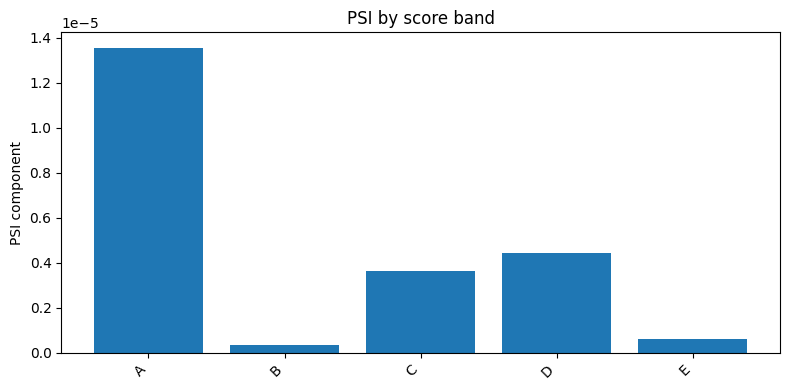

In [6]:
if train_scored is not None and test_scored is not None and "score_band" in train_scored.columns and "score_band" in test_scored.columns:
    expected_counts = train_scored["score_band"].value_counts().sort_index()
    actual_counts = test_scored["score_band"].value_counts().sort_index()

    all_bands = sorted(set(expected_counts.index).union(set(actual_counts.index)))
    expected_counts = expected_counts.reindex(all_bands, fill_value=0)
    actual_counts = actual_counts.reindex(all_bands, fill_value=0)

    psi_tbl = psi_by_band(expected_counts.values, actual_counts.values, labels=all_bands)
    print(psi_tbl)

    print("Total PSI:", round(float(psi_tbl["psi_total"].iloc[0]), 4))

    plt.figure(figsize=(8, 4))
    plt.bar(psi_tbl["band"].astype(str), psi_tbl["psi_component"])
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("PSI component")
    plt.title("PSI by score band")
    plt.tight_layout()
    plt.show()

    psi_tbl.to_csv(PROCESSED_DIR / "psi_by_score_band.csv", index=False)
else:
    print("Expected score_band column not found in train_scored/test_scored.")

## 6. Reject inference discussion

### Why this matters

In real lending data, the observed performance dataset usually contains only:
- approved applicants
- booked accounts
- then observed defaults/non-defaults

It does **not** fully observe what would have happened to rejected applicants.

This creates selection bias:
- the development sample is not the full applicant population
- the default relationship may differ if rejections had been booked

### Portfolio note

This notebook does not implement a full reject inference model.  
Instead, it documents the issue and shows awareness of a major real-world scorecard limitation.

### Common methods discussed in practice
- augmentation
- re-weighting
- parceling
- champion/challenger sensitivity testing

In [7]:
reject_inference_note = '''
Reject inference note:
- Development sample likely reflects approved/booked accounts only.
- Observed default outcomes are therefore conditional on historical acceptance policy.
- For portfolio demonstration purposes, this project documents the issue rather than implementing a production reject inference solution.
'''
print(reject_inference_note)


Reject inference note:
- Development sample likely reflects approved/booked accounts only.
- Observed default outcomes are therefore conditional on historical acceptance policy.
- For portfolio demonstration purposes, this project documents the issue rather than implementing a production reject inference solution.



## 7. Time-based validation split

### Why this matters

Random train/test splits are useful for learning, but scorecards are often validated on a **time-based split**.

That is closer to real bank use:
- build model on earlier period
- test on later period
- measure whether model ranking still holds in a more realistic out-of-time sample

In [8]:
DATE_COL = None  # e.g. "application_date"

def time_split(df, date_col, split_date):
    temp = df.copy()
    temp[date_col] = pd.to_datetime(temp[date_col])
    train = temp[temp[date_col] < pd.to_datetime(split_date)].copy()
    test = temp[temp[date_col] >= pd.to_datetime(split_date)].copy()
    return train, test

if train_scored is not None and DATE_COL is not None and DATE_COL in train_scored.columns:
    oot_train, oot_test = time_split(train_scored, DATE_COL, "2017-01-01")
    print("OOT train shape:", oot_train.shape)
    print("OOT test shape:", oot_test.shape)
else:
    print("Set DATE_COL and run against your full modelling base to build an out-of-time split.")

Set DATE_COL and run against your full modelling base to build an out-of-time split.


## 8. Calibration to long-run or through-the-cycle PD

### Why this matters

A logistic model often produces a point-in-time ranking signal.  
Banks may then calibrate model output toward:
- long-run average default rate
- through-the-cycle PD
- portfolio benchmark or policy target

This section shows a simple portfolio demonstration of that idea.

In [9]:
if test_scored is not None and "pd_pred" in test_scored.columns and "TARGET" in test_scored.columns:
    observed_dr = test_scored["TARGET"].mean()
    target_long_run_dr = observed_dr * 1.10  # example only; replace with benchmark or policy target

    calibrated_pd, adj_factor = long_run_calibration(
        raw_pd=test_scored["pd_pred"].values,
        observed_portfolio_dr=observed_dr,
        target_long_run_dr=target_long_run_dr
    )

    test_scored["pd_pred_calibrated"] = calibrated_pd

    print("Observed portfolio default rate:", round(float(observed_dr), 6))
    print("Target long-run default rate:", round(float(target_long_run_dr), 6))
    print("Calibration factor:", round(float(adj_factor), 6))

    calib_compare = pd.DataFrame({
        "raw_mean_pd": [test_scored["pd_pred"].mean()],
        "calibrated_mean_pd": [test_scored["pd_pred_calibrated"].mean()],
        "observed_default_rate": [observed_dr],
        "target_long_run_default_rate": [target_long_run_dr]
    })
    print(calib_compare)

    calib_compare.to_csv(PROCESSED_DIR / "calibration_summary.csv", index=False)
else:
    print("pd_pred and TARGET columns are required for calibration demo.")

Observed portfolio default rate: 0.080734
Target long-run default rate: 0.088807
Calibration factor: 1.1
   raw_mean_pd  calibrated_mean_pd  observed_default_rate  \
0     0.080452            0.088497               0.080734   

   target_long_run_default_rate  
0                      0.088807  


## 9. Score-to-grade mapping with portfolio default benchmarks

### Why this matters

A score is useful, but business teams often want:
- grades
- risk bands
- benchmark default rates

Example:
- Grade 1 = strongest segment
- Grade 8 = weakest segment

This is easier to use for:
- policy cut-offs
- portfolio monitoring
- management reporting

In [10]:
if test_scored is not None and "score" in test_scored.columns and "TARGET" in test_scored.columns:
    grade_summary = map_score_to_grade(
        test_scored,
        score_col="score",
        target_col="TARGET",
        grade_labels=None,
        n_grades=8
    )
    print(grade_summary)
    grade_summary.to_csv(PROCESSED_DIR / "score_to_grade_mapping.csv", index=False)
else:
    print("score and TARGET columns are required for score-to-grade mapping.")

                grade    obs  bads  default_rate grade_name
0    (49.74, 392.444]  11532  1277      0.110735         G1
1  (392.444, 445.465]  11532  1125      0.097555         G2
2  (445.465, 485.252]  11531  1025      0.088891         G3
3  (485.252, 522.769]  11532   856      0.074228         G4
4   (522.769, 553.62]  11532   937      0.081252         G5
5   (553.62, 592.362]  11532   785      0.068071         G6
6  (592.362, 637.182]  11531   799      0.069291         G7
7  (637.182, 829.293]  11532   644      0.055845         G8


C:\Users\siwan\AppData\Local\Temp\ipykernel_35148\282761654.py:62: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  temp.groupby("grade")[target_col]


## 10. Suggested interpretation for the portfolio README

This notebook shows that the scorecard project goes beyond model fitting and includes:

- manual monotonic review of bins  
- population monitoring through PSI  
- awareness of reject inference limitations  
- out-of-time validation design  
- PD calibration concepts  
- score-to-grade conversion for business use  

These are more aligned with real bank model lifecycle thinking than chasing a very small increase in AUC.